## W05 Decision Tree, cross validation and simple hyper parameter tuning

This example demostrates how to train a decision tree model and visualize the tree structure. It also shows how to perform hyper parameter tuning using random/gridded search.

The dataset used is a very simple house price data in Seattle. The label is the house price in $1000, and there are 8 housing attributes and the coordinates (location) of the house. The problem is to predict house price based on the given features.

Install sklearn if you haven't. 
https://scikit-learn.org/stable/install.html

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

In [2]:
file = 'https://raw.githubusercontent.com/Ziqi-Li/GIS5106/refs/heads/main/data/seattle_houses.geojson'

houses = gpd.read_file(file)

In [3]:
houses.head()

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price,price,geometry
0,74,3.00,3230,8625,10,3,0,3,17,544833.861947,5.267792e+06,6.100371,1260.0,POINT (5.45e+05 5.27e+06)
1,14667,2.50,2020,5501,7,3,0,0,5,564023.872203,5.260380e+06,5.618048,415.0,POINT (5.64e+05 5.26e+06)
2,2862,2.00,1340,3000,7,5,0,0,110,548855.802031,5.281573e+06,5.739572,549.0,POINT (5.49e+05 5.28e+06)
3,11095,3.75,3570,10125,10,3,0,0,1,558447.336282,5.268124e+06,6.204120,1600.0,POINT (5.58e+05 5.27e+06)
4,14791,2.00,1760,9055,7,4,0,0,30,565481.547734,5.278147e+06,5.662758,460.0,POINT (5.65e+05 5.28e+06)


In [4]:
y = houses['price']

X = houses[['bathrooms','view']]

## Data Split

We can split the data into training (80%) and testing (20%). The model will be trained based on the training data and the testing data will be used to evaluate the model accuracy.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Decision Tree 1 (max_depth=3)

Let us first try a tree with max_depth of 3

In [6]:
# Initialize the Decision Tree Regressor
dt1 = DecisionTreeRegressor(random_state=42,max_depth=3,criterion="squared_error")
dt1.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [7]:
# Make predictions on the testing set
y_pred = dt1.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2", r2)

Mean Squared Error: 120128.38994594371
R2 0.14094334195718317


The model's R2 = 0.14 which is not so great.

We can visualize how the predictions align with the real prices.

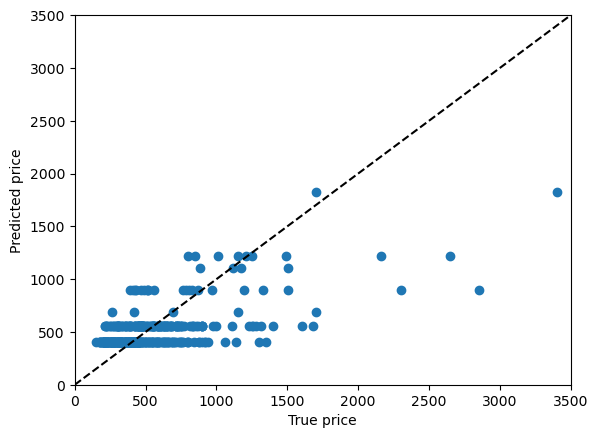

In [8]:
plt.scatter(y_test, y_pred)
plt.xlabel("True price")
plt.ylabel("Predicted price")

plt.xlim(0,3500) # limit the range of the axes
plt.ylim(0,3500)

plt.axline((0, 0), slope=1, color="k", linestyle="--") # diagnal line


The predictions are not so great.

### Here I use a package which is called `dtreeviz` to visualize the tree structure.

For installation of `dtreeviz`, please see here: https://github.com/parrt/dtreeviz

The vertical line marks the split at a node, and the horizonal line marks the average value of (y) after the split.

/Users/ziqili/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


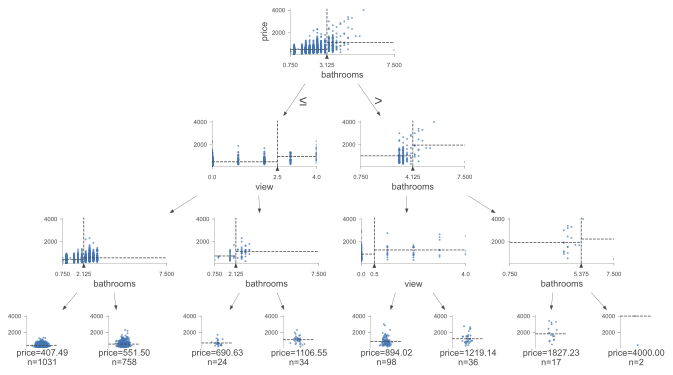

In [9]:
import dtreeviz

viz = dtreeviz.model(dt1, X, y,
                target_name="price",
                feature_names=X.columns)

viz.view()

From the decision tree it is noticable that having more bathrooms and better view will result in a higher property price.

### Decision Tree 2 (max_depth=4,min_samples_leaf=10 )

Let us train a deeper tree

In [10]:
dt2 = DecisionTreeRegressor(random_state=42,max_depth=4,min_samples_leaf=10)
dt2.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = dt2.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2", r2)


Mean Squared Error: 90618.60804356809
R2 0.3519723471077112


R2 is improved which indidates better accuracy.

/Users/ziqili/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


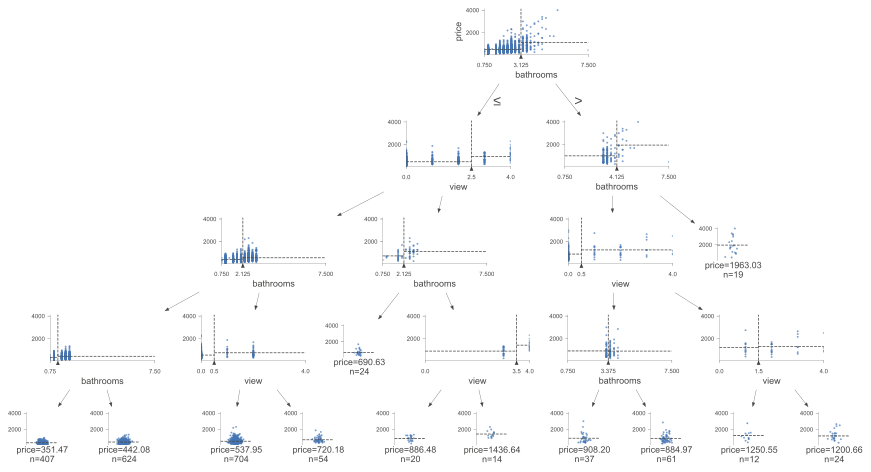

In [11]:
viz = dtreeviz.model(dt2, X, y,
                target_name="price",
                feature_names=X.columns)
viz.view()

## Automatic hyper parameter tuning

### Using a gridded or random search method to find the optimal hyperparameters

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

A grid search will try all the possible combinations of the hyperparameters you define in the grid. This might get overly slow if you have many hyperparameters and allow fine intervals.

Both search methods will involve a cross-validation, a common choice is to use `cv=5` which indicates a 5-fold cross validation.

In [13]:
# Define hyperparameter grid
param_grid = {
    'max_depth': [2, 4, 8, 16],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [10, 30, 50]
}

# Grid search
grid_search = GridSearchCV(dt1, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_) #The default score is R2

Best parameters: {'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 30}
Best score: 0.37945695089318254


You can then use the best model to make prediction

In [14]:
best_dt = grid_search.best_estimator_
best_dt

DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, min_samples_split=30,
                      random_state=42)

Similarly, here is a random search approach. Random search might be more efficient when your hyperparameter space is too large to allow a exhausive search. Here you can define the number of evaluations `n_iter=10` to limit the computation.

In [15]:
# Random search
random_search = RandomizedSearchCV(dt1, param_distributions=param_grid, n_iter=10, cv=5)
random_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters:", random_search.best_params_)
print("Best score:", random_search.best_score_) #The default score is R2

Best parameters: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 4}
Best score: 0.3675609545075978


## A full model
### Now lets use more variables to predict house price.

In [16]:
X_all = houses[['bathrooms', 'sqft_living', 'sqft_lot', 'grade',
       'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]


X_train_all, X_test_all, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

In [17]:
dt_all = DecisionTreeRegressor(random_state=42)
grid_search_all = GridSearchCV(dt_all, param_grid, cv=5)
grid_search_all.fit(X_train_all, y_train)

best_dt = grid_search_all.best_estimator_

print("Best parameters:", grid_search_all.best_params_)
print("Best score:", grid_search_all.best_score_) #The default score is R2

Best parameters: {'max_depth': 16, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best score: 0.6782015279267768


The new model has a much better R2 of 0.743

In [18]:
# Make predictions on the testing set
y_pred = best_dt.predict(X_test_all)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2", r2)


Mean Squared Error: 38999.325840801444
R2 0.7211098014566122


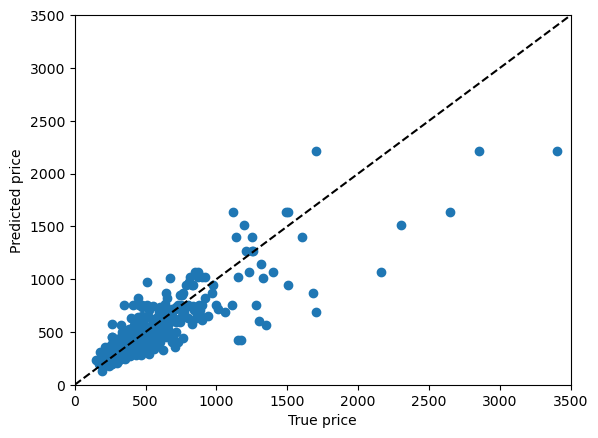

In [19]:
plt.scatter(y_test, y_pred)
plt.xlabel("True price")
plt.ylabel("Predicted price")

plt.xlim(0,3500) # limit the range of the axes
plt.ylim(0,3500)

plt.axline((0, 0), slope=1, color="k", linestyle="--") # diagnal line


The predictions are much better with hyper-parameter tuning as well as more variables included.

#### Visualize Feature importance, which feature is more important in the decision tree model

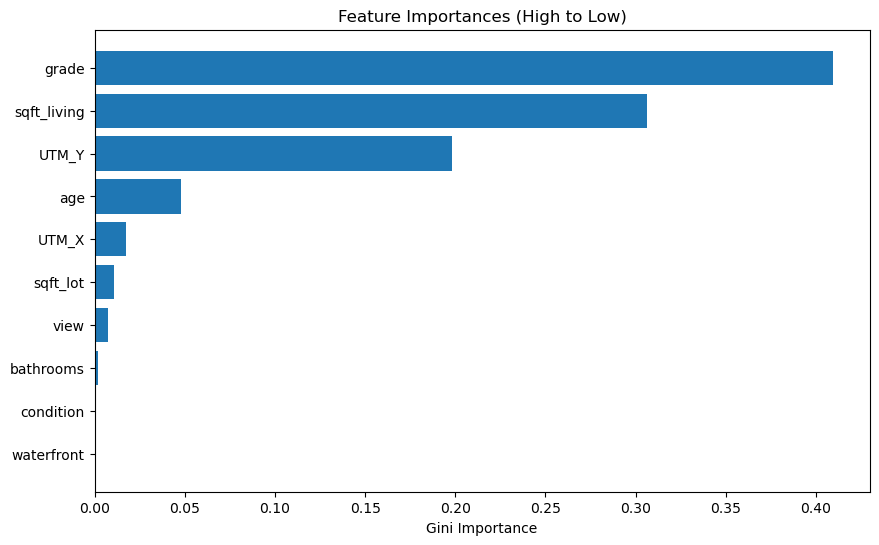

In [20]:
importances = best_dt.feature_importances_ #calculate importance

feature_importance_df = pd.DataFrame({
    'Feature': X_train_all.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


#Visualize the top features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Gini Importance')
plt.title('Feature Importances (High to Low)')
plt.gca().invert_yaxis()
plt.show()

Grade, sqft_living emerge as the top two most important features used by the decision tree in making the predictions.